# Bit Width 量化政策消融研究：回應助教 Q3 追問
## ViT-Small/16（RMSNorm）+ INT8 量化 on ImageNet-1k

> **助教 Q3**：將模型從 FP32 量化成 INT8 後，準確度下降了多少？
> **學生回答**：FP32 原本 ~74%，INT8 量化後掉到 ~60% 左右。
> **助教追問**：掉 10 幾 % 算滿多的，是否考慮過改用 12-bit 或 16-bit 等其他量化策略？

---

## 本 notebook 要回答的核心問題

學生原本的回答把「74% → 60%」的整整 **14pp** 全部歸因於 INT8 量化，
但這個歸因其實**不夠精確**。從 `【Phase0+1+ScaleTying】` notebook 的實際執行紀錄可知：

| 階段 | Top-1 | 說明 |
|------|-------|------|
| LayerNorm FP32（官方預訓練權重） | **74.17%** | 未經任何修改的 ViT-Small/16 AugReg |
| RMSNorm FP32（7-epoch 分段微調後） | **62.69%** | 換掉 LayerNorm、且僅用 46,429 張 ImageNet 子集微調 |
| RMSNorm + **INT8** PTQ Per-Channel | **62.61%** | 量化本身只掉 **0.08pp** |
| RMSNorm + **INT8** QAT Per-Channel | **63.13%** | 量化感知訓練後甚至**贏過** FP32 基準 |

也就是說，「74% → 62.69%」這 **11.48pp** 的下降，主因是**架構替換
（LayerNorm→RMSNorm）+ 訓練資料量受限**（僅 46K 張、7 epoch），
**INT8 量化本身只造成 0.08~0.76pp 的額外損失**（依粒度而定）。

這個 notebook 用同一個 ImageNet 切分 / 同一個 RMSNorm checkpoint，
系統化地把「量化造成的損失」與「架構/資料造成的損失」**解耦（decompose）**，
並針對助教的追問，把 bit width 從 INT4 一路掃到 INT16（含 FP16），
同時涵蓋校準策略、量化粒度、混合精度、QAT 恢復能力，
最後用統計檢定（McNemar's test）與硬體成本（DRAM 頻寬 / BRAM / DSP48 封裝效率）
量化說明：**為什麼 12-bit / 16-bit 不是更好的選擇**。

## 實驗設計

| 實驗組 | 內容 |
|--------|------|
| EXP-DECOMP | 解耦：LN-FP32 → RMS-FP32 → INT8，量化出每一段各掉多少 |
| EXP-FP16   | FP16 半精度（GPU 原生支援，免重訓） |
| EXP-BW     | PTQ Per-Channel：INT4 / INT6 / INT8 / INT12 / INT16 精度-位元曲線 |
| EXP-GRAN   | INT8 / INT12 / INT16 × Per-Tensor / Per-Channel / Per-Block 粒度交叉 |
| EXP-CAL    | INT8 Per-Channel 下，MinMax vs Percentile 校準策略 |
| EXP-SENS   | 逐層敏感度分析（INT8 fake-quant 對 logit 的 MSE 影響） |
| EXP-MP     | 混合精度：保護高敏感層（FP32/INT12/INT16），其餘 INT8 |
| EXP-QAT    | QAT-STE：INT4/6/8/12/16 的精度恢復曲線（3 epoch，與 Phase0+1 同協定） |
| EXP-HW     | PYNQ-Z2 硬體可行性：DRAM 頻寬、BRAM、DSP48E1 封裝效率 |
| EXP-STAT   | McNemar's Test：每個方案 vs RMS-FP32 基準是否顯著 |

**模型**：`vit_small_patch16_224.augreg_in21k_ft_in1k`（timm，RMSNorm 版）
**資料集**：`IMAGENET_VAL_HF` 本地子集，46,429 張 / 1000 類，
80/20 stratified split（SEED=42，與 Phase0+1+ScaleTying notebook 完全相同切分）
**前置 checkpoint**：`./ckpt_rms_quant/rms_stage_b.pt`（RMS-FP32，7-epoch 分段訓練結果）


## Cell 0：套件確認

In [1]:
import subprocess, sys
for pkg in ['timm', 'scipy', 'scikit-learn', 'seaborn', 'tqdm', 'pandas']:
    try:
        __import__(pkg.replace('-', '_').replace('scikit_learn', 'sklearn'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Dependencies ready.')

Dependencies ready.


## Cell 1：繁體中文字型設定

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

ZH_CANDIDATES = ["Microsoft JhengHei", "Noto Sans TC", "Noto Serif TC", "DFKai-SB", "MingLiU"]
available = {f.name for f in fm.fontManager.ttflist}
ZH_FONT = next((f for f in ZH_CANDIDATES if f in available), None)
if ZH_FONT:
    matplotlib.rcParams['font.family'] = ZH_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False
    print(f'中文字型：{ZH_FONT}')
else:
    print('未找到中文字型，圖表中文可能顯示方框')

中文字型：Microsoft JhengHei


## Cell 2：匯入函式庫 + 全域設定

In [3]:
import os, time, copy, math, random, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
from scipy.stats import chi2 as chi2_dist
from sklearn.metrics import f1_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'timm     : {timm.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

# ── 路徑：沿用 Phase0+1+ScaleTying 的 RMS-FP32 checkpoint，結果另存新資料夾 ──
IMAGENET_VAL_DIR = os.path.abspath('./IMAGENET_VAL_HF')
PREV_CKPT_DIR    = './ckpt_rms_quant'
CKPT_DIR         = './ckpt_bitwidth_policy'
RES_DIR          = './bitwidth_policy_results'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RES_DIR,  exist_ok=True)

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
BATCH_TRAIN   = 64
BATCH_EVAL    = 128
NUM_WORKERS_TRAIN = 6
NUM_WORKERS_EVAL  = 4

# ── 本研究主角：bit width 全掃描 ──────────────────────────────────────────
BW_LIST    = [4, 6, 8, 12, 16]
QAT_EPOCHS = 3       # 與 Phase0+1+ScaleTying 的 QAT 協定相同，方便比較
QAT_LR     = 2e-5

# ── PYNQ-Z2（Zynq XC7Z020）硬體規格，與 Profiling_README.md / gen_profiling_nb.py 一致 ──
FREQ      = 200e6     # 200 MHz
DSP_TOT   = 220       # Xilinx DSP48E1 數量
BRAM36    = 140       # BRAM36 數量
BRAM_KB   = BRAM36 * 36 / 8   # = 630 KB
DMA_BW    = 1.2e9     # AXI-DMA 有效頻寬 (bytes/s) = FREQ * 6.0 B/cycle

# ── 規格書 v3.1 標準（與 Phase0+1+ScaleTying 一致）──────────────────────
SPEC_INT8_THRESHOLD = -0.3   # INT8 量化 ΔAcc 規格下限 (pp)

print(f'\nImageNet 路徑   : {IMAGENET_VAL_DIR}')
print(f'  存在          : {os.path.isdir(IMAGENET_VAL_DIR)}')
print(f'RMS-FP32 ckpt   : {PREV_CKPT_DIR}/rms_stage_b.pt')
print(f'  存在          : {os.path.exists(PREV_CKPT_DIR + "/rms_stage_b.pt")}')
print(f'結果輸出        : {CKPT_DIR} , {RES_DIR}')
print(f'Bit Width 掃描  : {BW_LIST}')
print(f'PYNQ-Z2 規格    : FREQ={FREQ/1e6:.0f}MHz  DSP={DSP_TOT}  BRAM={BRAM_KB:.0f}KB  DRAM_BW={DMA_BW/1e9:.1f}GB/s')

PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA     : True
GPU      : NVIDIA GeForce RTX 5060

ImageNet 路徑   : C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\整理中\IMAGENET_VAL_HF
  存在          : True
RMS-FP32 ckpt   : ./ckpt_rms_quant/rms_stage_b.pt
  存在          : True
結果輸出        : ./ckpt_bitwidth_policy , ./bitwidth_policy_results
Bit Width 掃描  : [4, 6, 8, 12, 16]
PYNQ-Z2 規格    : FREQ=200MHz  DSP=220  BRAM=630KB  DRAM_BW=1.2GB/s


## Cell 3：ImageNet 資料集載入 + 80/20 Stratified Split

**重要**：切分邏輯（SEED、stratify 比例、calib 抽樣方式）與
`【Phase0+1+ScaleTying】RMSNorm_INT8_ScaleTying_ImageNet.ipynb` 的 Step 2 完全相同，
確保載入同一個 `rms_stage_b.pt` checkpoint 後，在 `test_loader` 上能重現 **62.69%** 的基準準確率。

In [4]:
assert os.path.isdir(IMAGENET_VAL_DIR), f'路徑不存在：{IMAGENET_VAL_DIR}'

transform_eval = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_train = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

inet_eval  = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_eval)
inet_train = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_train)

cls_to_idx = {}
for idx, (_, label) in enumerate(inet_eval.samples):
    cls_to_idx.setdefault(label, []).append(idx)

rng = random.Random(SEED)
train_idx, test_idx, calib_idx = [], [], []
for label, indices in cls_to_idx.items():
    s = indices[:]; rng.shuffle(s)
    n_tr = int(len(s) * 0.8)
    train_idx.extend(s[:n_tr])
    test_idx.extend(s[n_tr:])
    calib_idx.extend(s[:1])

train_loader = DataLoader(Subset(inet_train, train_idx), batch_size=BATCH_TRAIN,
                          shuffle=True,  num_workers=NUM_WORKERS_TRAIN, pin_memory=True)
test_loader  = DataLoader(Subset(inet_eval,  test_idx),  batch_size=BATCH_EVAL,
                          shuffle=False, num_workers=NUM_WORKERS_EVAL,  pin_memory=True)
calib_loader = DataLoader(Subset(inet_eval,  calib_idx), batch_size=BATCH_EVAL,
                          shuffle=False, num_workers=NUM_WORKERS_EVAL,  pin_memory=True)

print(f'資料集 : {len(inet_eval):,} 張 / {len(inet_eval.classes)} 類')
print(f'訓練集 : {len(train_idx):,} 張   測試集 : {len(test_idx):,} 張   校準集 : {len(calib_idx)} 張')
assert len(train_idx) == 36720 and len(test_idx) == 9709, \
    '切分結果與 Phase0+1+ScaleTying 不一致！請確認 IMAGENET_VAL_HF 內容未變更。'
print('切分驗證通過：與 Phase0+1+ScaleTying notebook 完全一致（36,720 / 9,709 / 1,000）')

資料集 : 46,429 張 / 1000 類
訓練集 : 36,720 張   測試集 : 9,709 張   校準集 : 1000 張
切分驗證通過：與 Phase0+1+ScaleTying notebook 完全一致（36,720 / 9,709 / 1,000）


## Cell 4：RMSNorm 模組 + 工具函數

In [5]:
class RMSNorm(nn.Module):
    '''Root Mean Square Layer Normalization（Zhang & Sennrich, 2019），與 nn.LayerNorm 介面相容'''
    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()
        self.normalized_shape = (normalized_shape,) if isinstance(normalized_shape, int) \
                                  else tuple(normalized_shape)
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        self.weight = nn.Parameter(torch.ones(self.normalized_shape)) if elementwise_affine else None
        self.bias = None

    def forward(self, x):
        orig = x.dtype
        xf = x.float()
        inv = torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + self.eps)
        out = xf * inv
        if self.weight is not None:
            out = out * self.weight.float()
        return out.to(orig)

    def extra_repr(self):
        return f'shape={self.normalized_shape}, eps={self.eps}'


def find_norm_layers(model, norm_type):
    result = []
    for name, mod in model.named_modules():
        if isinstance(mod, norm_type):
            parts = name.split('.'); parent = model
            for p in parts[:-1]: parent = getattr(parent, p)
            result.append({'full_name': name, 'attr': parts[-1], 'parent': parent, 'module': mod})
    return result


def replace_ln_with_rms(model, copy_weights=True):
    lns = find_norm_layers(model, nn.LayerNorm)
    for info in lns:
        ln = info['module']
        rms = RMSNorm(ln.normalized_shape, eps=ln.eps, elementwise_affine=(ln.weight is not None))
        if copy_weights and ln.weight is not None:
            with torch.no_grad():
                rms.weight.copy_(ln.weight)
        setattr(info['parent'], info['attr'], rms)
    return len(lns)


def get_module(model, name):
    m = model
    for p in name.split('.'): m = getattr(m, p)
    return m


@torch.no_grad()
def evaluate(model, loader, device=None, half=False):
    if device is None: device = DEVICE
    model.eval().to(device)
    all_preds, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        if half: x = x.half()
        preds = model(x).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(y)
    preds_all  = torch.cat(all_preds).numpy()
    labels_all = torch.cat(all_labels).numpy()
    acc = float((preds_all == labels_all).mean()) * 100.0
    f1  = float(f1_score(labels_all, preds_all, average='macro'))
    return acc, f1, preds_all, labels_all


def param_count(model):
    return sum(p.numel() for p in model.parameters())


ALL_RESULTS = {}   # exp_id -> {method, bits, acc, f1, preds, extra}
def save_result(exp_id, method, bits, acc, f1, preds, extra=None):
    ALL_RESULTS[exp_id] = {'method': method, 'bits': bits, 'acc': acc, 'f1': f1,
                           'preds': preds, 'extra': extra or {}}

print('RMSNorm / 工具函數 定義完成')

RMSNorm / 工具函數 定義完成


## Cell 5：EXP-DECOMP — 解耦「架構/資料」與「量化」造成的精度損失

依序評估：
1. **LN-FP32**：官方預訓練權重（未動過，74.17% 為快取值，與 Phase0+1+ScaleTying 一致）
2. **RMS-FP32**：載入 `rms_stage_b.pt`（RMSNorm 替換 + 7-epoch 分段微調後）— 在本 notebook 重新評估取得 preds，作為後續所有量化實驗的基準
3. **RMS-FP32 + INT8 PTQ Per-Channel**：複現 Phase0+1+ScaleTying 的量化結果

藉此明確區分：「74%→62.69%」是架構替換+資料量受限的代價，
「62.69%→62.61%」才是 INT8 量化本身的代價。

In [6]:
print('載入 ViT-Small/16 AugReg 預訓練模型...')
model_ln_base = timm.create_model('vit_small_patch16_224.augreg_in21k_ft_in1k',
                                  pretrained=True, num_classes=1000)
model_ln_base.eval()

model_rms = copy.deepcopy(model_ln_base)
n_replaced = replace_ln_with_rms(model_rms, copy_weights=True)
print(f'替換 {n_replaced} 個 LayerNorm -> RMSNorm')

RMS_CKPT = f'{PREV_CKPT_DIR}/rms_stage_b.pt'
assert os.path.exists(RMS_CKPT), f'找不到 checkpoint：{RMS_CKPT}（需先執行 Phase0+1+ScaleTying notebook）'
model_rms.load_state_dict(torch.load(RMS_CKPT, map_location=DEVICE))
model_rms.to(DEVICE)

# ── 1) LN-FP32：讀取 Phase0+1+ScaleTying 的快取值（避免重複跑 46K 張全資料集）──
CACHE_LN = f'{PREV_CKPT_DIR}/acc_ln_pretrain.txt'
acc_ln_base = float(open(CACHE_LN).read()) if os.path.exists(CACHE_LN) else None
print(f'\n[快取] LN-FP32 預訓練基準（全資料集 46,429 張）：{acc_ln_base:.2f}%')

# 在本 notebook 的 test_loader（9,709 張）上也評估一次 LN-FP32，取得 preds 供 McNemar 檢定
t0 = time.time()
acc_ln_test, f1_ln_test, preds_ln, test_labels = evaluate(model_ln_base, test_loader)
print(f'[本次測試集] LN-FP32：{acc_ln_test:.2f}%  Macro-F1={f1_ln_test:.4f}  ({time.time()-t0:.1f}s)')

# ── 2) RMS-FP32：本 notebook 的量化基準 ──────────────────────────────────
t0 = time.time()
fp32_acc, fp32_f1, fp32_preds, test_labels = evaluate(model_rms, test_loader)
print(f'[本次測試集] RMS-FP32：{fp32_acc:.2f}%  Macro-F1={fp32_f1:.4f}  ({time.time()-t0:.1f}s)')
print(f'  （Phase0+1+ScaleTying 快取值：62.69%，差異應 ~0，confirm 切分/checkpoint 一致）')

n_params = param_count(model_rms)
print(f'\n模型參數量：{n_params/1e6:.2f}M')

save_result('EXP-DECOMP-LN', 'LN-FP32 (pretrained)', 32, acc_ln_test, f1_ln_test, preds_ln)
save_result('EXP-DECOMP-RMS', 'RMS-FP32 (baseline)', 32, fp32_acc, fp32_f1, fp32_preds)

print('\n=== 解耦摘要（本 notebook test_loader, n=9,709）===')
print(f'  LN-FP32  -> RMS-FP32   ΔAcc = {fp32_acc - acc_ln_test:+.2f}pp  （架構替換 + 訓練資料受限）')
print(f'  （INT8 量化造成的損失將於 EXP-BW 中呈現，預期遠小於上述數字）')

載入 ViT-Small/16 AugReg 預訓練模型...


替換 25 個 LayerNorm -> RMSNorm

[快取] LN-FP32 預訓練基準（全資料集 46,429 張）：74.17%


[本次測試集] LN-FP32：74.27%  Macro-F1=0.7414  (28.4s)


[本次測試集] RMS-FP32：62.69%  Macro-F1=0.6235  (27.9s)
  （Phase0+1+ScaleTying 快取值：62.69%，差異應 ~0，confirm 切分/checkpoint 一致）

模型參數量：22.04M

=== 解耦摘要（本 notebook test_loader, n=9,709）===
  LN-FP32  -> RMS-FP32   ΔAcc = -11.58pp  （架構替換 + 訓練資料受限）
  （INT8 量化造成的損失將於 EXP-BW 中呈現，預期遠小於上述數字）


## Cell 6：通用量化工具函數（任意 bit width × 任意粒度）

In [7]:
def compute_scale_generic(W: torch.Tensor, bits: int, granularity='per_channel',
                          percentile: float = 100.0):
    '''計算 symmetric quantization scale。granularity: per_channel / per_tensor'''
    q_max = 2 ** (bits - 1) - 1
    if percentile < 100.0:
        if granularity == 'per_channel' and W.dim() >= 2:
            W2d = W.abs().view(W.size(0), -1)
            t = torch.quantile(W2d, percentile / 100., dim=1)
            return t.clamp(min=1e-8).view(-1, 1) / q_max, q_max
        else:
            t = torch.quantile(W.abs().flatten(), percentile / 100.)
            return (t.clamp(min=1e-8) / q_max).view(1), q_max

    if granularity == 'per_channel' and W.dim() >= 2:
        max_v = W.abs().view(W.size(0), -1).max(dim=1).values
        return max_v.clamp(min=1e-8).view(-1, 1) / q_max, q_max
    else:
        max_v = W.abs().max()
        return (max_v.clamp(min=1e-8) / q_max).view(1), q_max


def fake_quant_tensor(W: torch.Tensor, bits: int, granularity='per_channel',
                      percentile: float = 100.0):
    scale, q_max = compute_scale_generic(W, bits, granularity, percentile)
    q_min = -(2 ** (bits - 1))
    return torch.clamp(torch.round(W / scale), q_min, q_max) * scale


def get_quant_layer_names(model):
    '''所有可量化的 nn.Linear 層（含 head，與 Phase0+1+ScaleTying 的 PTQ 慣例一致）'''
    return [n for n, m in model.named_modules() if isinstance(m, nn.Linear)]


def quantize_model_bits(model_fp32, bits, granularity='per_channel', percentile: float = 100.0):
    '''PTQ：對所有 nn.Linear 套用 fake quantization（含 head）'''
    model_q = copy.deepcopy(model_fp32).eval()
    n = 0
    with torch.no_grad():
        for m in model_q.modules():
            if not isinstance(m, nn.Linear): continue
            m.weight.data = fake_quant_tensor(m.weight.data, bits, granularity, percentile)
            n += 1
    return model_q, n


def quantize_model_perblock(model_fp32, bits):
    '''PTQ Per-Block（Scale Tying）：同一 Transformer Block 內所有 Linear 共用 1 個 scale。
    與 Phase0+1+ScaleTying 的 quantize_ptq_perblock 邏輯相同，只是 bits 可變。
    patch_embed / head 不在 blocks 內，保留 FP32。'''
    model_q = copy.deepcopy(model_fp32).eval()
    q_max = 2 ** (bits - 1) - 1
    blk_scales = []
    with torch.no_grad():
        for blk in model_q.blocks:
            linears = [m for m in blk.modules() if isinstance(m, nn.Linear)]
            if not linears:
                blk_scales.append(0.0); continue
            max_abs = max(m.weight.data.abs().max().item() for m in linears)
            scale = max(max_abs / q_max, 1e-9)
            blk_scales.append(scale)
            for m in linears:
                W = m.weight.data
                m.weight.data = torch.clamp(torch.round(W / scale), -q_max, q_max) * scale
    return model_q, blk_scales


quant_layer_names = get_quant_layer_names(model_rms)
print(f'可量化層數（含 head）：{len(quant_layer_names)}')
print('通用量化工具函數定義完成（compute_scale_generic / fake_quant_tensor / '
      'quantize_model_bits / quantize_model_perblock）')

可量化層數（含 head）：49
通用量化工具函數定義完成（compute_scale_generic / fake_quant_tensor / quantize_model_bits / quantize_model_perblock）


## Cell 7：EXP-FP16 — FP16 半精度（GPU 原生支援，免重訓）

與先前在 CPU 環境下嘗試（FP16 matmul 在 CPU 上多數 kernel 未實作）不同，
這裡在 GPU（RTX 5060，Tensor Core 原生支援 FP16）上直接評估，
理論上應幾乎不損失精度，且記憶體減半。

In [8]:
print('=== EXP-FP16：半精度 ===')
model_fp16 = copy.deepcopy(model_rms).half().to(DEVICE)
t0 = time.time()
acc_fp16, f1_fp16, preds_fp16, _ = evaluate(model_fp16, test_loader, half=True)
print(f'Top-1={acc_fp16:.2f}%  Macro-F1={f1_fp16:.4f}  '
      f'Drop={(fp32_acc - acc_fp16):+.3f}pp  ({time.time()-t0:.1f}s)')

fp16_bytes = sum(p.numel() * 2 for p in model_fp16.parameters())
fp32_bytes = sum(p.numel() * 4 for p in model_rms.parameters())
print(f'記憶體：FP32={fp32_bytes/1e6:.1f}MB -> FP16={fp16_bytes/1e6:.1f}MB '
      f'（{fp32_bytes/fp16_bytes:.1f}x 縮減）')

save_result('EXP-FP16', 'FP16', 16, acc_fp16, f1_fp16, preds_fp16, {'memory_mb': fp16_bytes/1e6})
del model_fp16
torch.cuda.empty_cache() if torch.cuda.is_available() else None

=== EXP-FP16：半精度 ===


Top-1=62.69%  Macro-F1=0.6234  Drop=+0.000pp  (29.1s)
記憶體：FP32=88.2MB -> FP16=44.1MB （2.0x 縮減）


## Cell 8：EXP-BW — PTQ Bit Width 掃描（INT4 / INT6 / INT8 / INT12 / INT16）

固定校準策略（MinMax，Per-Channel，Symmetric），只改變 bit width，
直接回應助教「考慮過 12-bit / 16-bit 嗎」的問題：在同一個 RMS-FP32 基準上，
INT12 / INT16 相對 INT8 究竟能換回多少精度。

In [9]:
bw_results = {}
for bits in BW_LIST:
    label = f'INT{bits}'
    print(f'--- {label}（per-channel, symmetric, MinMax）---')
    t0 = time.time()
    mq, n_layers = quantize_model_bits(model_rms, bits, granularity='per_channel')
    mq.to(DEVICE)
    acc, f1, preds, _ = evaluate(mq, test_loader)
    elapsed = time.time() - t0
    drop = fp32_acc - acc
    bw_results[label] = {'bits': bits, 'acc': acc, 'f1': f1, 'drop_pp': drop, 'preds': preds}
    print(f'  {n_layers} 層量化  Top-1={acc:.2f}%  F1={f1:.4f}  Drop={drop:+.3f}pp  ({elapsed:.1f}s)')
    save_result(f'EXP-BW-{label}', f'PTQ-MinMax-PC-{label}', bits, acc, f1, preds,
                {'granularity': 'per_channel', 'calib': 'minmax'})
    del mq
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\n=== Bit Width 精度摘要（基準：RMS-FP32 = {:.2f}%）==='.format(fp32_acc))
print(f'{"Bits":>6} {"Method":>8} {"Top-1":>8} {"Macro-F1":>10} {"Drop(pp)":>10}')
print(f'{32:>6} {"FP32":>8} {fp32_acc:>8.2f} {fp32_f1:>10.4f} {0.0:>10.2f}')
print(f'{16:>6} {"FP16":>8} {acc_fp16:>8.2f} {f1_fp16:>10.4f} {fp32_acc-acc_fp16:>10.3f}')
for label, r in bw_results.items():
    print(f'{r["bits"]:>6} {label:>8} {r["acc"]:>8.2f} {r["f1"]:>10.4f} {r["drop_pp"]:>10.3f}')

--- INT4（per-channel, symmetric, MinMax）---


  49 層量化  Top-1=51.27%  F1=0.5101  Drop=+11.422pp  (29.9s)
--- INT6（per-channel, symmetric, MinMax）---


  49 層量化  Top-1=62.19%  F1=0.6183  Drop=+0.505pp  (29.9s)
--- INT8（per-channel, symmetric, MinMax）---


  49 層量化  Top-1=62.61%  F1=0.6225  Drop=+0.082pp  (29.2s)
--- INT12（per-channel, symmetric, MinMax）---


  49 層量化  Top-1=62.72%  F1=0.6237  Drop=-0.021pp  (29.6s)
--- INT16（per-channel, symmetric, MinMax）---


  49 層量化  Top-1=62.70%  F1=0.6236  Drop=-0.010pp  (29.6s)

=== Bit Width 精度摘要（基準：RMS-FP32 = 62.69%）===
  Bits   Method    Top-1   Macro-F1   Drop(pp)
    32     FP32    62.69     0.6235       0.00
    16     FP16    62.69     0.6234      0.000
     4     INT4    51.27     0.5101     11.422
     6     INT6    62.19     0.6183      0.505
     8     INT8    62.61     0.6225      0.082
    12    INT12    62.72     0.6237     -0.021
    16    INT16    62.70     0.6236     -0.010


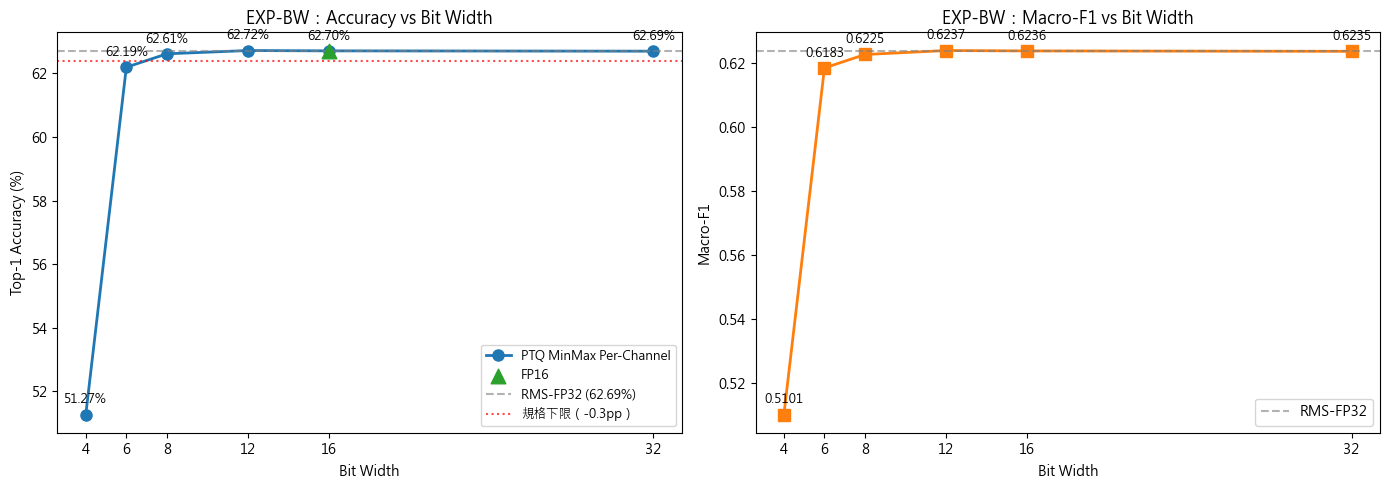

已儲存：./bitwidth_policy_results/exp_bw_curve.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bit_pts = BW_LIST + [32]
acc_pts = [bw_results[f'INT{b}']['acc'] for b in BW_LIST] + [fp32_acc]
f1_pts  = [bw_results[f'INT{b}']['f1']  for b in BW_LIST] + [fp32_f1]

ax = axes[0]
ax.plot(bit_pts, acc_pts, 'o-', color='#1f77b4', lw=2, ms=8, label='PTQ MinMax Per-Channel')
ax.scatter([16], [acc_fp16], marker='^', s=110, color='#2ca02c', zorder=5, label='FP16')
ax.axhline(fp32_acc, color='gray', ls='--', alpha=0.6, label=f'RMS-FP32 ({fp32_acc:.2f}%)')
ax.axhline(fp32_acc + SPEC_INT8_THRESHOLD, color='red', ls=':', alpha=0.7,
           label=f'規格下限（{SPEC_INT8_THRESHOLD}pp）')
for x, y in zip(bit_pts, acc_pts):
    ax.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('Bit Width'); ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('EXP-BW：Accuracy vs Bit Width'); ax.set_xticks(sorted(set(bit_pts)))
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(bit_pts, f1_pts, 's-', color='#ff7f0e', lw=2, ms=8)
ax.axhline(fp32_f1, color='gray', ls='--', alpha=0.6, label='RMS-FP32')
for x, y in zip(bit_pts, f1_pts):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('Bit Width'); ax.set_ylabel('Macro-F1')
ax.set_title('EXP-BW：Macro-F1 vs Bit Width'); ax.set_xticks(sorted(set(bit_pts))); ax.legend()

plt.tight_layout()
plt.savefig(f'{RES_DIR}/exp_bw_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/exp_bw_curve.png')

## Cell 9：EXP-GRAN — 量化粒度 × Bit Width 交叉分析

延伸 Phase0+1+ScaleTying 的 Scale Tying 分析：不只在 INT8，
也在 **INT12 / INT16** 下比較 Per-Tensor / Per-Channel / Per-Block 三種粒度。
驗證「即使提高 bit width，Per-Block（硬體最省）粒度的損失能否被蓋過」。

In [11]:
GRAN_BITS = [8, 12, 16]
gran_results = {}
for bits in GRAN_BITS:
    for gran in ['per_tensor', 'per_channel']:
        label = f'INT{bits}-{"PT" if gran=="per_tensor" else "PC"}'
        mq, _ = quantize_model_bits(model_rms, bits, granularity=gran)
        mq.to(DEVICE)
        acc, f1, preds, _ = evaluate(mq, test_loader)
        gran_results[label] = {'bits': bits, 'gran': gran, 'acc': acc, 'f1': f1,
                               'drop_pp': fp32_acc - acc, 'preds': preds}
        print(f'  {label:<14} Top-1={acc:.2f}%  Drop={fp32_acc-acc:+.3f}pp')
        save_result(f'EXP-GRAN-{label}', f'PTQ INT{bits} {gran}', bits, acc, f1, preds,
                    {'granularity': gran})
        del mq
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Per-Block
    mq, blk_scales = quantize_model_perblock(model_rms, bits)
    mq.to(DEVICE)
    acc, f1, preds, _ = evaluate(mq, test_loader)
    label = f'INT{bits}-PB'
    gran_results[label] = {'bits': bits, 'gran': 'per_block', 'acc': acc, 'f1': f1,
                           'drop_pp': fp32_acc - acc, 'preds': preds, 'blk_scales': blk_scales}
    print(f'  {label:<14} Top-1={acc:.2f}%  Drop={fp32_acc-acc:+.3f}pp  '
          f'({len(blk_scales)} tied scales)')
    save_result(f'EXP-GRAN-{label}', f'PTQ INT{bits} per_block', bits, acc, f1, preds,
                {'granularity': 'per_block'})
    del mq
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\n=== Per-Tensor vs Per-Channel vs Per-Block Gap ===')
for bits in GRAN_BITS:
    pc = gran_results[f'INT{bits}-PC']['acc']
    pt = gran_results[f'INT{bits}-PT']['acc']
    pb = gran_results[f'INT{bits}-PB']['acc']
    print(f'  INT{bits}: PC={pc:.2f}%  PT={pt:.2f}%（{pt-pc:+.2f}pp）  '
          f'PB={pb:.2f}%（{pb-pc:+.2f}pp）')

  INT8-PT        Top-1=62.14%  Drop=+0.556pp


  INT8-PC        Top-1=62.61%  Drop=+0.082pp


  INT8-PB        Top-1=61.93%  Drop=+0.762pp  (12 tied scales)


  INT12-PT       Top-1=62.74%  Drop=-0.041pp


  INT12-PC       Top-1=62.72%  Drop=-0.021pp


  INT12-PB       Top-1=62.69%  Drop=+0.000pp  (12 tied scales)


  INT16-PT       Top-1=62.72%  Drop=-0.021pp


  INT16-PC       Top-1=62.70%  Drop=-0.010pp


  INT16-PB       Top-1=62.70%  Drop=-0.010pp  (12 tied scales)

=== Per-Tensor vs Per-Channel vs Per-Block Gap ===
  INT8: PC=62.61%  PT=62.14%（-0.47pp）  PB=61.93%（-0.68pp）
  INT12: PC=62.72%  PT=62.74%（+0.02pp）  PB=62.69%（-0.02pp）
  INT16: PC=62.70%  PT=62.72%（+0.01pp）  PB=62.70%（+0.00pp）


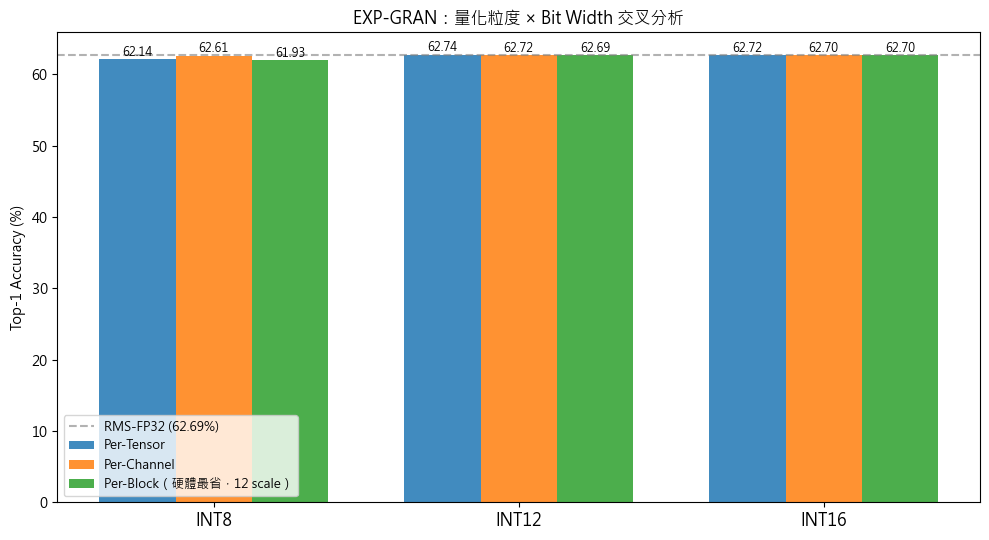

已儲存：./bitwidth_policy_results/exp_gran.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(GRAN_BITS)); width = 0.25
pt_accs = [gran_results[f'INT{b}-PT']['acc'] for b in GRAN_BITS]
pc_accs = [gran_results[f'INT{b}-PC']['acc'] for b in GRAN_BITS]
pb_accs = [gran_results[f'INT{b}-PB']['acc'] for b in GRAN_BITS]

bars1 = ax.bar(x - width, pt_accs, width, label='Per-Tensor',  color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x,         pc_accs, width, label='Per-Channel', color='#ff7f0e', alpha=0.85)
bars3 = ax.bar(x + width, pb_accs, width, label='Per-Block（硬體最省，12 scale）',
               color='#2ca02c', alpha=0.85)
ax.axhline(fp32_acc, color='gray', ls='--', alpha=0.6, label=f'RMS-FP32 ({fp32_acc:.2f}%)')

for bars, vals in [(bars1, pt_accs), (bars2, pc_accs), (bars3, pb_accs)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels([f'INT{b}' for b in GRAN_BITS], fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('EXP-GRAN：量化粒度 × Bit Width 交叉分析')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{RES_DIR}/exp_gran.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/exp_gran.png')

## Cell 10：EXP-CAL — 校準策略消融（固定 INT8 Per-Channel）

比較 MinMax 與不同 Percentile 截斷策略，確認在 INT8 下校準策略對精度的影響量級，
作為與 bit-width 影響量級的對照。

  INT8 PC [MinMax    ] Top-1=62.61%  Drop=+0.082pp


  INT8 PC [Pct-99.9% ] Top-1=62.14%  Drop=+0.556pp


  INT8 PC [Pct-99.99%] Top-1=62.62%  Drop=+0.072pp


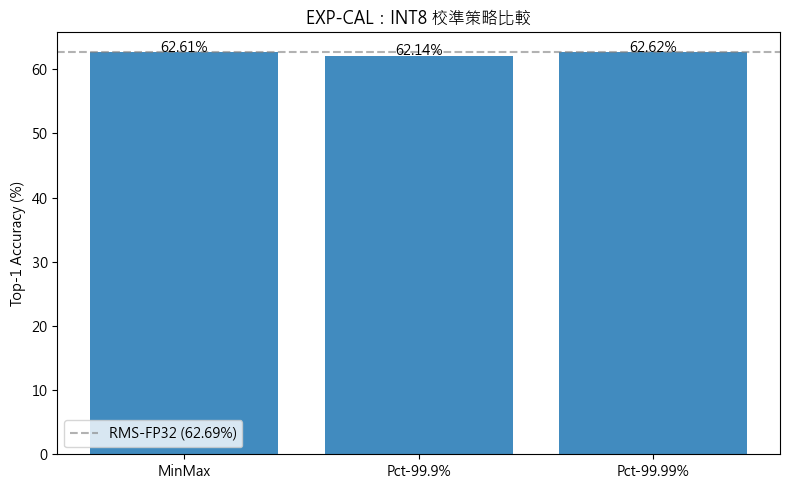

已儲存：./bitwidth_policy_results/exp_cal.png


In [13]:
CAL_CONFIGS = [
    {'label': 'MinMax',      'pct': 100.0},
    {'label': 'Pct-99.9%',   'pct': 99.9},
    {'label': 'Pct-99.99%',  'pct': 99.99},
]
cal_results = {}
for cfg in CAL_CONFIGS:
    lbl = cfg['label']
    mq, _ = quantize_model_bits(model_rms, 8, granularity='per_channel', percentile=cfg['pct'])
    mq.to(DEVICE)
    acc, f1, preds, _ = evaluate(mq, test_loader)
    cal_results[lbl] = {'acc': acc, 'f1': f1, 'drop_pp': fp32_acc - acc, 'preds': preds}
    print(f'  INT8 PC [{lbl:<10}] Top-1={acc:.2f}%  Drop={fp32_acc-acc:+.3f}pp')
    save_result(f'EXP-CAL-{lbl}', f'PTQ-INT8-PC-{lbl}', 8, acc, f1, preds,
                {'calibration': lbl, 'percentile': cfg['pct']})
    del mq
    if torch.cuda.is_available(): torch.cuda.empty_cache()

fig, ax = plt.subplots(figsize=(8, 5))
names = list(cal_results.keys())
accs  = [cal_results[n]['acc'] for n in names]
ax.bar(names, accs, color='#1f77b4', alpha=0.85)
ax.axhline(fp32_acc, color='gray', ls='--', alpha=0.6, label=f'RMS-FP32 ({fp32_acc:.2f}%)')
for i, v in enumerate(accs):
    ax.text(i, v + 0.03, f'{v:.2f}%', ha='center', fontsize=10)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('EXP-CAL：INT8 校準策略比較')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RES_DIR}/exp_cal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/exp_cal.png')

## Cell 11：EXP-SENS — 逐層敏感度分析

對每一層做「單層 INT8 量化」並量測 logit 的 MSE 變化，
找出對量化最敏感的層（前 25%），作為混合精度（EXP-MP）的保護目標。

執行逐層敏感度分析（INT8 per-channel）...


Sensitivity:   0%|                                       | 0/49 [00:00<?, ?it/s]

Sensitivity:   2%|▋                              | 1/49 [00:14<11:44, 14.68s/it]

Sensitivity:   4%|█▎                             | 2/49 [00:28<11:11, 14.29s/it]

Sensitivity:   6%|█▉                             | 3/49 [00:41<10:33, 13.78s/it]

...

Sensitivity:  96%|████████████████████████████▊ | 47/49 [10:19<00:26, 13.09s/it]

Sensitivity:  98%|█████████████████████████████▍| 48/49 [10:32<00:13, 13.13s/it]

Sensitivity: 100%|██████████████████████████████| 49/49 [10:45<00:00, 13.06s/it]

Sensitivity: 100%|██████████████████████████████| 49/49 [10:45<00:00, 13.17s/it]

完成，耗時 645.2s
             Layer      MSE Type
  blocks.0.mlp.fc2 0.000366  FFN
  blocks.0.mlp.fc1 0.000117  FFN
 blocks.10.mlp.fc2 0.000116  FFN
              head 0.000108 Head
blocks.0.attn.proj 0.000097 Attn
  blocks.9.mlp.fc2 0.000086  FFN
  blocks.8.mlp.fc2 0.000073  FFN
 blocks.10.mlp.fc1 0.000069  FFN
  blocks.6.mlp.fc2 0.000066  FFN
blocks.11.attn.qkv 0.000061 Attn


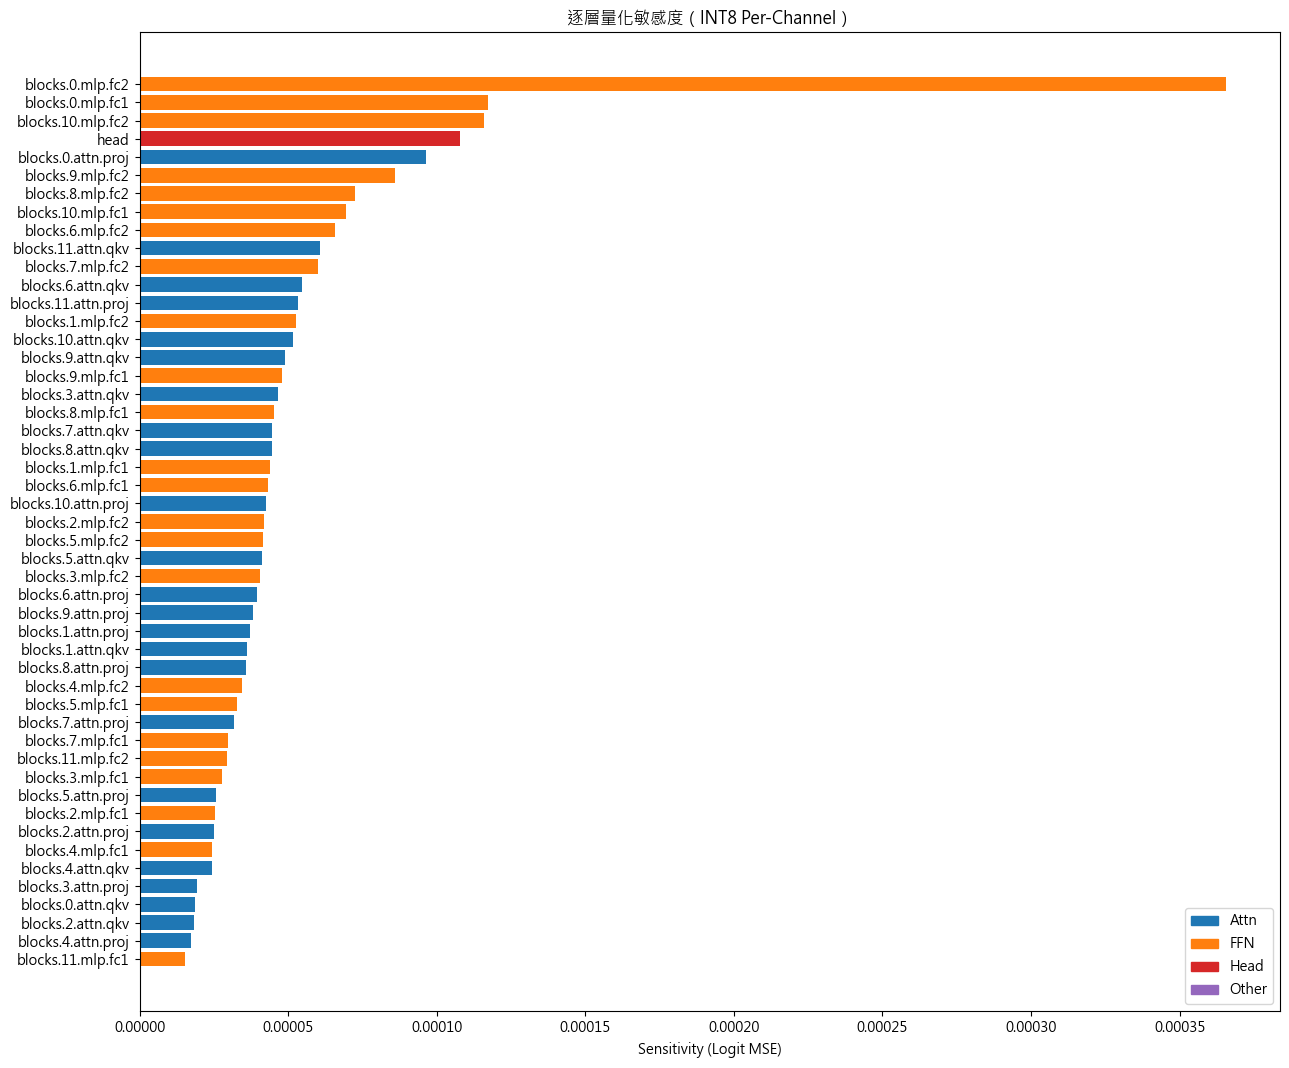


高敏感層（前 25%，n=13）：
  blocks.0.mlp.fc2
  blocks.0.mlp.fc1
  blocks.10.mlp.fc2
  head
  blocks.0.attn.proj
  blocks.9.mlp.fc2
  blocks.8.mlp.fc2
  blocks.10.mlp.fc1
  blocks.6.mlp.fc2
  blocks.11.attn.qkv
  blocks.7.mlp.fc2
  blocks.6.attn.qkv
  blocks.11.attn.proj


In [14]:
def compute_sensitivity(model, calib_loader, layer_name, bits=8, granularity='per_channel'):
    m = get_module(model, layer_name)
    w0 = m.weight.data.clone()
    m.weight.data = fake_quant_tensor(w0, bits, granularity=granularity)
    model.eval()
    imgs, _ = next(iter(calib_loader))
    imgs = imgs.to(DEVICE)
    with torch.no_grad():
        logits_q = model(imgs).cpu()
    m.weight.data.copy_(w0)
    with torch.no_grad():
        logits_fp = model(imgs).cpu()
    return float(((logits_fp - logits_q) ** 2).mean())

print('執行逐層敏感度分析（INT8 per-channel）...')
t0 = time.time()
sens = {}
for name in tqdm(quant_layer_names, desc='Sensitivity', ncols=80):
    sens[name] = compute_sensitivity(model_rms, calib_loader, name, bits=8)
print(f'完成，耗時 {time.time()-t0:.1f}s')

df_sens = pd.DataFrame(sorted(sens.items(), key=lambda x: x[1], reverse=True),
                       columns=['Layer', 'MSE'])
df_sens['Type'] = df_sens['Layer'].apply(
    lambda n: 'Attn' if 'attn' in n else 'FFN' if 'mlp' in n else
              'Head' if n == 'head' else 'Other')
print(df_sens.head(10).to_string(index=False))

color_map = {'Attn': '#1f77b4', 'FFN': '#ff7f0e', 'Head': '#d62728', 'Other': '#9467bd'}
colors = [color_map[t] for t in df_sens['Type']]
fig, ax = plt.subplots(figsize=(13, max(5, len(df_sens) * 0.22)))
ax.barh(df_sens['Layer'], df_sens['MSE'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Sensitivity (Logit MSE)')
ax.set_title('逐層量化敏感度（INT8 Per-Channel）')
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in color_map.items()])
plt.tight_layout()
plt.savefig(f'{RES_DIR}/sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

threshold = df_sens['MSE'].quantile(0.75)
high_sens_layers = df_sens[df_sens['MSE'] >= threshold]['Layer'].tolist()
print(f'\n高敏感層（前 25%，n={len(high_sens_layers)}）：')
for l in high_sens_layers: print(f'  {l}')

## Cell 12：EXP-MP — 混合精度（保護高敏感層）

策略：高敏感層（前 25%）保留更高精度（FP32 / INT16 / INT12），其餘壓縮至 INT8 Per-Channel。
驗證「只把少數敏感層升到 12/16-bit」是否能用更小的硬體代價換回大部分精度。

In [15]:
MP_CONFIGS = [
    ('EXP-MP-FP32',  'INT8(bulk)+FP32(sensitive)',  'skip',  None),
    ('EXP-MP-INT16', 'INT8(bulk)+INT16(sensitive)', 'bits',  16),
    ('EXP-MP-INT12', 'INT8(bulk)+INT12(sensitive)', 'bits',  12),
]
mp_results = {}
for exp_id, label, mode, bits in MP_CONFIGS:
    model_mp, _ = quantize_model_bits(model_rms, 8, granularity='per_channel')
    model_fp32_cpu = model_rms  # 來源權重（FP32）

    for name in high_sens_layers:
        src_m = get_module(model_fp32_cpu, name)
        dst_m = get_module(model_mp, name)
        if mode == 'skip':
            dst_m.weight.data.copy_(src_m.weight.data)
        else:
            dst_m.weight.data = fake_quant_tensor(src_m.weight.data.clone(), bits,
                                                   granularity='per_channel')

    model_mp.to(DEVICE)
    acc, f1, preds, _ = evaluate(model_mp, test_loader)
    mp_results[label] = {'acc': acc, 'f1': f1, 'drop_pp': fp32_acc - acc, 'preds': preds,
                         'n_protected': len(high_sens_layers)}
    print(f'  {label:<32} Top-1={acc:.2f}%  Drop={fp32_acc-acc:+.3f}pp  '
          f'(protected {len(high_sens_layers)}/{len(quant_layer_names)} 層)')
    save_result(exp_id, label, '8+mix', acc, f1, preds, {'n_protected': len(high_sens_layers)})
    del model_mp
    if torch.cuda.is_available(): torch.cuda.empty_cache()

int8_acc = bw_results['INT8']['acc']
print(f'\n=== 混合精度 vs 純 INT8（{int8_acc:.2f}%）精度回收 ===')
for label, r in mp_results.items():
    print(f'  {label:<32} Gain over pure INT8: {r["acc"]-int8_acc:+.3f}pp')

  INT8(bulk)+FP32(sensitive)       Top-1=62.67%  Drop=+0.021pp  (protected 13/49 層)


  INT8(bulk)+INT16(sensitive)      Top-1=62.66%  Drop=+0.031pp  (protected 13/49 層)


  INT8(bulk)+INT12(sensitive)      Top-1=62.66%  Drop=+0.031pp  (protected 13/49 層)

=== 混合精度 vs 純 INT8（62.61%）精度回收 ===
  INT8(bulk)+FP32(sensitive)       Gain over pure INT8: +0.062pp
  INT8(bulk)+INT16(sensitive)      Gain over pure INT8: +0.051pp
  INT8(bulk)+INT12(sensitive)      Gain over pure INT8: +0.051pp


## Cell 13：QAT-STE 通用工具（任意 bit width）

延伸 Phase0+1+ScaleTying 的 `QuantLinearSTE`，加入 `bits` 參數，
使同一套 QAT 訓練流程可套用在 INT4 / INT6 / INT8 / INT12 / INT16。
LLRD（layer-wise learning rate decay）與 cosine schedule 與原 notebook 完全相同。

In [16]:
class STEQuantFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, max_int):
        return torch.clamp(torch.round(x / scale), -max_int, max_int) * scale
    @staticmethod
    def backward(ctx, grad):
        return grad, None, None    # STE：梯度直接穿透 round


class QuantLinearSTE_NBit(nn.Linear):
    '''Per-Channel QAT Linear，bits 可配置（INT4~INT16 通用）'''
    def __init__(self, in_features, out_features, bias, bits=8):
        super().__init__(in_features, out_features, bias)
        self.bits = bits
        self.q_max = 2 ** (bits - 1) - 1

    def forward(self, x):
        scale = (self.weight.abs().max(dim=1, keepdim=True)[0] / self.q_max
                ).detach().clamp(1e-9)
        if self.training:
            w_fq = STEQuantFunc.apply(self.weight, scale, self.q_max)
        else:
            w_fq = torch.clamp(torch.round(self.weight / scale), -self.q_max, self.q_max) * scale
        return F.linear(x, w_fq, self.bias)


def inject_ste_nbit(model_fp32, bits, skip_head=True):
    '''替換所有 Linear（除 head）為 QuantLinearSTE_NBit，與基準 QAT 設置一致'''
    model_q = copy.deepcopy(model_fp32)
    head_mod = getattr(model_q, 'head', None)
    n = 0
    for parent in list(model_q.modules()):
        for name, child in list(parent.named_children()):
            if not isinstance(child, nn.Linear): continue
            if skip_head and child is head_mod: continue
            new = QuantLinearSTE_NBit(child.in_features, child.out_features,
                                      child.bias is not None, bits=bits)
            new.weight.data.copy_(child.weight.data)
            if child.bias is not None: new.bias.data.copy_(child.bias.data)
            setattr(parent, name, new)
            n += 1
    return model_q, n


def get_llrd_groups(model, base_lr, decay=0.85):
    n = len(model.blocks); gs = []
    head_ps = [p for p in model.head.parameters() if p.requires_grad]
    for attr in ('norm', 'fc_norm'):
        if hasattr(model, attr):
            head_ps += [p for p in getattr(model, attr).parameters() if p.requires_grad]
    if head_ps: gs.append({'params': head_ps, 'lr': base_lr, 'name': 'head'})
    for i in range(n - 1, -1, -1):
        blk_ps = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if blk_ps:
            gs.append({'params': blk_ps, 'lr': base_lr * (decay ** (n - i)), 'name': f'block_{i}'})
    emb_ps = []
    if hasattr(model, 'patch_embed'):
        emb_ps += [p for p in model.patch_embed.parameters() if p.requires_grad]
    for attr in ('cls_token', 'pos_embed'):
        if hasattr(model, attr):
            p = getattr(model, attr)
            if isinstance(p, nn.Parameter) and p.requires_grad: emb_ps.append(p)
    if emb_ps:
        gs.append({'params': emb_ps, 'lr': base_lr * (decay ** (n + 1)), 'name': 'embed'})
    return gs


def qat_train_nbit(model, train_loader, test_loader, epochs, lr, save_path, tag):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(get_llrd_groups(model, lr, decay=0.85), weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))
    history, best_acc = [], 0.0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        model.train(); ep_loss = ep_n = 0
        for x, y in tqdm(train_loader, desc=f'[{tag} Ep{ep}/{epochs}]', leave=False, ncols=80):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            ep_loss += loss.item() * y.size(0); ep_n += y.size(0)
        avg_loss = ep_loss / ep_n
        acc, f1, preds, _ = evaluate(model, test_loader)
        history.append({'epoch': ep, 'loss': avg_loss, 'acc': acc, 'f1': f1})
        print(f'[{tag}] Ep {ep}/{epochs}  loss={avg_loss:.4f}  acc={acc:.2f}%  '
              f'f1={f1:.4f}  ({time.time()-t0:.0f}s)')
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)
    return history, best_acc


print('QAT-STE 通用工具定義完成（QuantLinearSTE_NBit / inject_ste_nbit / qat_train_nbit）')

QAT-STE 通用工具定義完成（QuantLinearSTE_NBit / inject_ste_nbit / qat_train_nbit）


## Cell 14：EXP-QAT — QAT-STE 在 INT4/6/8/12/16 下的精度恢復曲線

每個 bit width 訓練 3 epoch（與 Phase0+1+ScaleTying 的 QAT 協定相同：epochs=3, lr=2e-5），
觀察 QAT 能否讓低 bit width（INT4/6）追上 PTQ 的高 bit width（INT12/16），
以及 INT12/16 經過 QAT 後是否還能比 INT8-QAT 多換到精度。

In [17]:
qat_results = {}
qat_histories = {}

for bits in BW_LIST:
    save_path = f'{CKPT_DIR}/rms_qat_int{bits}_best.pt'
    acc_cache = f'{CKPT_DIR}/acc_qat_int{bits}.txt'
    tag = f'QAT-INT{bits}'
    print(f'\n{"="*60}\n {tag}：{QAT_EPOCHS} epoch（LR={QAT_LR}）\n{"="*60}')

    model_qat, n_replaced = inject_ste_nbit(model_rms, bits)
    model_qat.to(DEVICE)
    print(f'  替換 {n_replaced} 個 Linear（head 保留 FP32）')

    if os.path.exists(acc_cache) and os.path.exists(save_path):
        print(f'  [快取] 載入既有 checkpoint')
        model_qat.load_state_dict(torch.load(save_path, map_location=DEVICE))
        acc, f1, preds, _ = evaluate(model_qat, test_loader)
        qat_histories[bits] = []
    else:
        hist, best_acc = qat_train_nbit(model_qat, train_loader, test_loader,
                                        QAT_EPOCHS, QAT_LR, save_path, tag)
        model_qat.load_state_dict(torch.load(save_path, map_location=DEVICE))
        acc, f1, preds, _ = evaluate(model_qat, test_loader)
        open(acc_cache, 'w').write(str(acc))
        qat_histories[bits] = hist

    drop = fp32_acc - acc
    qat_results[bits] = {'acc': acc, 'f1': f1, 'drop_pp': drop, 'preds': preds}
    print(f'[{tag}] 最終 Top-1={acc:.2f}%  F1={f1:.4f}  Drop={drop:+.3f}pp')
    save_result(f'EXP-QAT-INT{bits}', f'QAT-STE-INT{bits}', bits, acc, f1, preds)
    del model_qat
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\n=== QAT 全部完成 ===')
for bits in BW_LIST:
    r = qat_results[bits]
    print(f'  INT{bits:<3}  Top-1={r["acc"]:.2f}%  Drop={r["drop_pp"]:+.3f}pp')


 QAT-INT4：3 epoch（LR=2e-05）
  替換 48 個 Linear（head 保留 FP32）


[QAT-INT4 Ep1/3]:   0%|                                 | 0/574 [00:00<?, ?it/s]

[QAT-INT4 Ep1/3]:   0%|                       | 1/574 [00:17<2:43:17, 17.10s/it]

[QAT-INT4 Ep1/3]:   0%|                       | 2/574 [00:17<1:08:39,  7.20s/it]

[QAT-INT4 Ep1/3]:   1%|▏                        | 3/574 [00:17<38:25,  4.04s/it]

...

[QAT-INT16 Ep3/3]: 100%|█████████████████████▉| 572/574 [02:55<00:00,  3.56it/s]

[QAT-INT16 Ep3/3]: 100%|█████████████████████▉| 573/574 [02:56<00:00,  3.56it/s]

[QAT-INT16 Ep3/3]: 100%|██████████████████████| 574/574 [02:56<00:00,  3.85it/s]

[QAT-INT16] Ep 3/3  loss=1.2469  acc=63.20%  f1=0.6287  (207s)


[QAT-INT16] 最終 Top-1=63.20%  F1=0.6287  Drop=-0.505pp

=== QAT 全部完成 ===
  INT4    Top-1=61.22%  Drop=+1.473pp
  INT6    Top-1=63.24%  Drop=-0.546pp
  INT8    Top-1=63.24%  Drop=-0.546pp
  INT12   Top-1=63.35%  Drop=-0.659pp
  INT16   Top-1=63.20%  Drop=-0.505pp


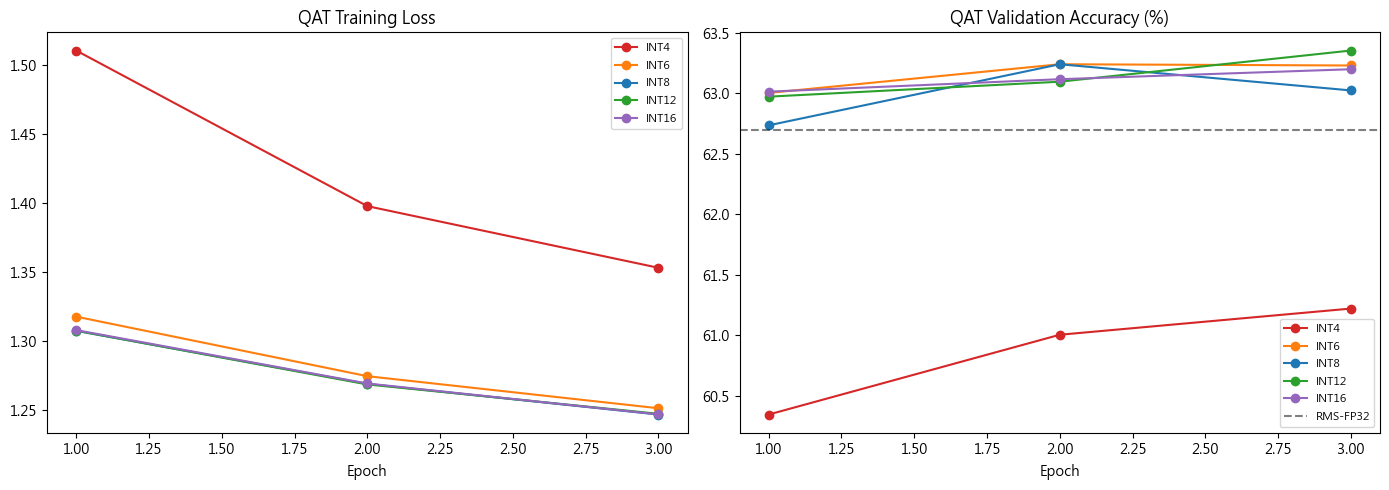

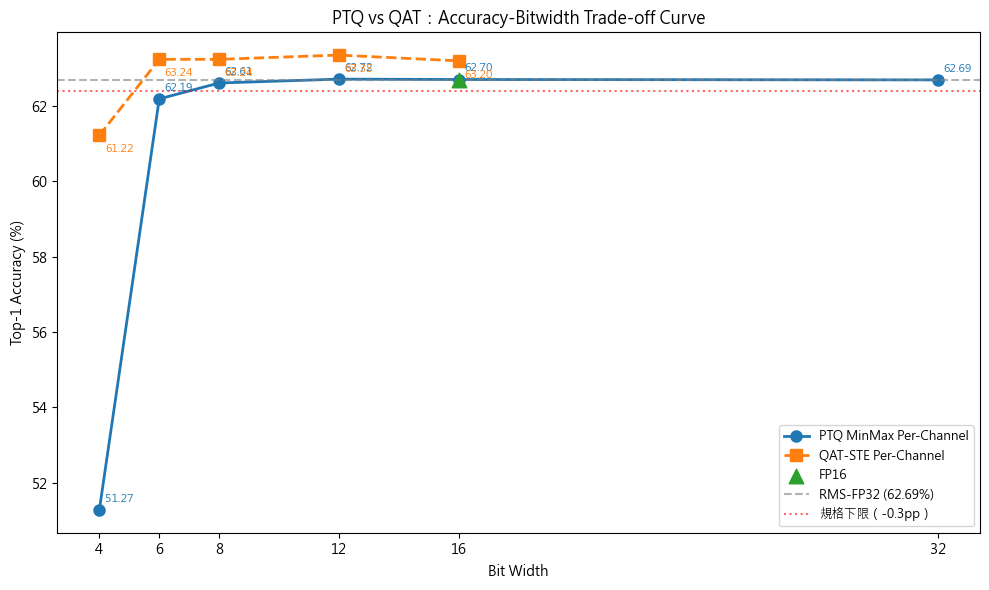

已儲存：./bitwidth_policy_results/exp_qat_curves.png , ./bitwidth_policy_results/ptq_vs_qat_curve.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_qat = {4: '#d62728', 6: '#ff7f0e', 8: '#1f77b4', 12: '#2ca02c', 16: '#9467bd'}
has_hist = any(len(qat_histories[b]) > 0 for b in BW_LIST)
if has_hist:
    for bits in BW_LIST:
        hist = qat_histories[bits]
        if not hist: continue
        c = colors_qat[bits]
        eps = [h['epoch'] for h in hist]
        axes[0].plot(eps, [h['loss'] for h in hist], 'o-', color=c, label=f'INT{bits}')
        axes[1].plot(eps, [h['acc']  for h in hist], 'o-', color=c, label=f'INT{bits}')
    axes[1].axhline(fp32_acc, color='k', ls='--', alpha=0.5, label='RMS-FP32')
    axes[0].set_title('QAT Training Loss'); axes[1].set_title('QAT Validation Accuracy (%)')
    for ax in axes: ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{RES_DIR}/exp_qat_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('（全部從快取載入，無訓練曲線可畫）')
    plt.close(fig)

# PTQ vs QAT 對比曲線
fig, ax = plt.subplots(figsize=(10, 6))
ptq_bits = BW_LIST + [32]
ptq_accs = [bw_results[f'INT{b}']['acc'] for b in BW_LIST] + [fp32_acc]
qat_bits = BW_LIST
qat_accs = [qat_results[b]['acc'] for b in BW_LIST]

ax.plot(ptq_bits, ptq_accs, 'o-', color='#1f77b4', lw=2, ms=8, label='PTQ MinMax Per-Channel')
ax.plot(qat_bits, qat_accs, 's--', color='#ff7f0e', lw=2, ms=8, label='QAT-STE Per-Channel')
ax.scatter([16], [acc_fp16], marker='^', s=110, color='#2ca02c', zorder=5, label='FP16')
ax.axhline(fp32_acc, color='gray', ls='--', alpha=0.6, label=f'RMS-FP32 ({fp32_acc:.2f}%)')
ax.axhline(fp32_acc + SPEC_INT8_THRESHOLD, color='red', ls=':', alpha=0.6,
           label=f'規格下限（{SPEC_INT8_THRESHOLD}pp）')
for x, y in zip(ptq_bits, ptq_accs):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(4, 6),
                fontsize=8, color='#1f77b4')
for x, y in zip(qat_bits, qat_accs):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(4, -12),
                fontsize=8, color='#ff7f0e')
ax.set_xlabel('Bit Width'); ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('PTQ vs QAT：Accuracy-Bitwidth Trade-off Curve')
ax.set_xticks(sorted(set(ptq_bits))); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{RES_DIR}/ptq_vs_qat_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/exp_qat_curves.png , {RES_DIR}/ptq_vs_qat_curve.png')

## Cell 15：EXP-HW — PYNQ-Z2 硬體可行性：DRAM 頻寬 / BRAM / DSP48E1 封裝效率

關鍵硬體事實（Xilinx DSP48E1，25×18 乘法器）：
- **INT8 × INT8**：兩個 INT8 乘法可以「打包」進 1 個 DSP48E1（18-bit 輸入容納 2 個 8-bit 操作數）
  → **2 MACs/DSP**
- **INT12 / INT16**：操作數超過可打包寬度，每個 DSP48E1 只能做 **1 個** 乘法
  → **1 MAC/DSP**（吞吐量直接減半，或要 2 倍 DSP 才能打平吞吐量）

這是「即使精度幾乎沒差，也不該隨意升到 12/16-bit」的**硬體面**理由，
與 EXP-BW/EXP-QAT 呈現的「**精度面**幾乎沒差」互相佐證。

Linear 層權重元素數：21,617,664（FP32 = 86.47 MB）

=== 硬體成本估算（PYNQ-Z2, DRAM_BW=1.2GB/s, DSP=220）===
 bits label  weight_mb  dram_ms  macs_per_dsp  eff_dsp_macs
   32  FP32  86.470656 72.05888             1           220
   16  FP16  43.235328 36.02944             1           220
   16 INT16  43.235328 36.02944             1           220
   12 INT12  32.426496 27.02208             1           220
    8  INT8  21.617664 18.01472             2           440
    6  INT6  16.213248 13.51104             2           440
    4  INT4  10.808832  9.00736             2           440


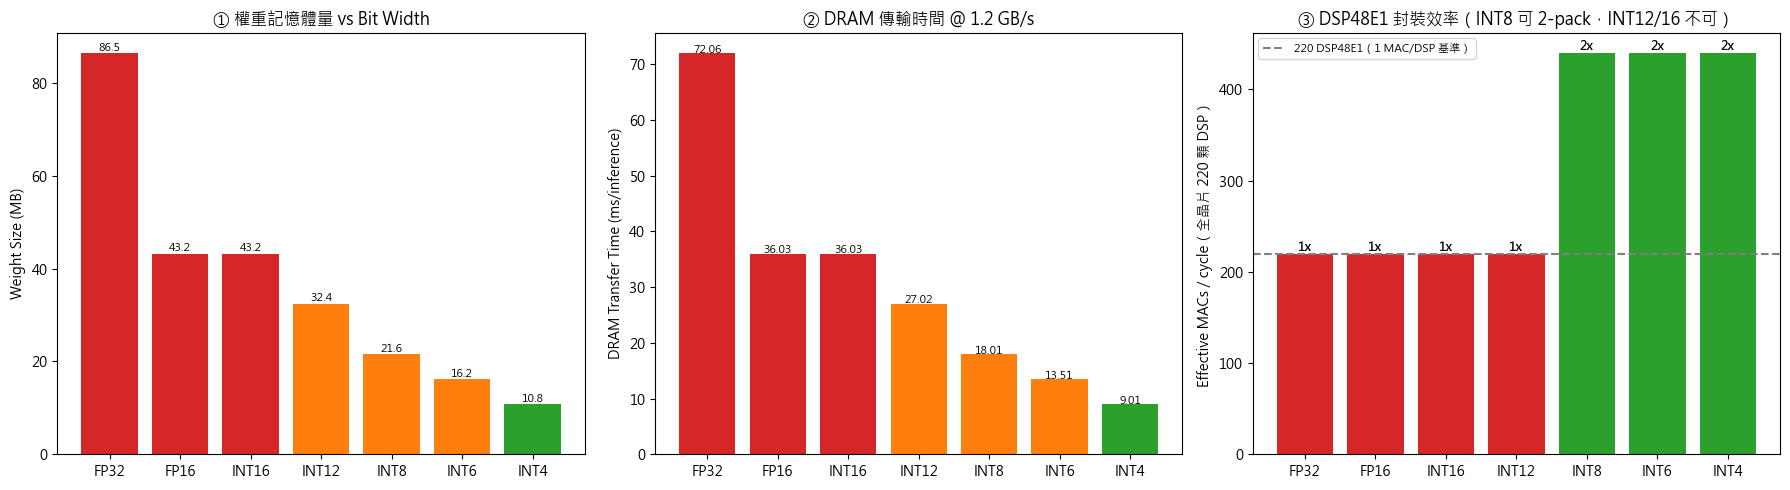

已儲存：./bitwidth_policy_results/hw_estimate.png

結論：INT12/INT16 相對 INT8，DSP 吞吐量直接砍半（440→220 effective MACs/cycle），
      DRAM 傳輸時間增加 1.5x（INT12/INT8） ~ 2.0x（INT16/INT8）。


In [19]:
# 模型權重量（僅 Linear 層，貼近實際硬體資料流）
total_weight_elems = sum(m.weight.numel() for m in model_rms.modules() if isinstance(m, nn.Linear))
total_weight_bytes_fp32 = total_weight_elems * 4
print(f'Linear 層權重元素數：{total_weight_elems:,}（FP32 = {total_weight_bytes_fp32/1e6:.2f} MB）')

hw_rows = []
for bits, label in [(32, 'FP32'), (16, 'FP16'), (16, 'INT16'), (12, 'INT12'),
                     (8, 'INT8'), (6, 'INT6'), (4, 'INT4')]:
    bytes_per_elem = bits / 8.0
    weight_mb = total_weight_elems * bytes_per_elem / 1e6
    dram_ms   = (weight_mb * 1e6) / DMA_BW * 1e3     # ms / inference（權重搬運）
    macs_per_dsp = 2 if bits <= 8 else 1
    eff_dsp_macs = DSP_TOT * macs_per_dsp            # 全晶片每 cycle 的 MAC 數
    hw_rows.append({'bits': bits, 'label': label, 'weight_mb': weight_mb,
                    'dram_ms': dram_ms, 'macs_per_dsp': macs_per_dsp,
                    'eff_dsp_macs': eff_dsp_macs})

df_hw = pd.DataFrame(hw_rows)
print('\n=== 硬體成本估算（PYNQ-Z2, DRAM_BW={:.1f}GB/s, DSP={}）==='.format(DMA_BW/1e9, DSP_TOT))
print(df_hw.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_hw = [r['label'] for r in hw_rows]
clrs = ['#d62728' if r['weight_mb'] > 40 else '#ff7f0e' if r['weight_mb'] > 15 else '#2ca02c'
        for r in hw_rows]

ax = axes[0]
ax.bar(labels_hw, [r['weight_mb'] for r in hw_rows], color=clrs)
ax.set_ylabel('Weight Size (MB)'); ax.set_title('① 權重記憶體量 vs Bit Width')
for i, r in enumerate(hw_rows):
    ax.text(i, r['weight_mb']+0.5, f"{r['weight_mb']:.1f}", ha='center', fontsize=8)

ax = axes[1]
ax.bar(labels_hw, [r['dram_ms'] for r in hw_rows], color=clrs)
ax.set_ylabel('DRAM Transfer Time (ms/inference)')
ax.set_title(f'② DRAM 傳輸時間 @ {DMA_BW/1e9:.1f} GB/s')
for i, r in enumerate(hw_rows):
    ax.text(i, r['dram_ms']+0.05, f"{r['dram_ms']:.2f}", ha='center', fontsize=8)

ax = axes[2]
macs_colors = ['#2ca02c' if r['macs_per_dsp'] == 2 else '#d62728' for r in hw_rows]
ax.bar(labels_hw, [r['eff_dsp_macs'] for r in hw_rows], color=macs_colors)
ax.axhline(DSP_TOT, color='gray', ls='--', label=f'{DSP_TOT} DSP48E1（1 MAC/DSP 基準）')
ax.set_ylabel('Effective MACs / cycle（全晶片 220 顆 DSP）')
ax.set_title('③ DSP48E1 封裝效率（INT8 可 2-pack，INT12/16 不可）')
for i, r in enumerate(hw_rows):
    ax.text(i, r['eff_dsp_macs']+3, f"{r['macs_per_dsp']}x", ha='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RES_DIR}/hw_estimate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/hw_estimate.png')
print(f'\n結論：INT12/INT16 相對 INT8，DSP 吞吐量直接砍半（{DSP_TOT*2}→{DSP_TOT} effective MACs/cycle），'
      f'\n      DRAM 傳輸時間增加 {hw_rows[3]["dram_ms"]/hw_rows[4]["dram_ms"]:.1f}x（INT12/INT8）'
      f' ~ {hw_rows[2]["dram_ms"]/hw_rows[4]["dram_ms"]:.1f}x（INT16/INT8）。')

## Cell 16：EXP-STAT — McNemar's Test（統計顯著性）

對所有量化方案 vs **RMS-FP32 基準**做 McNemar 檢定：
- p > 0.05：與 FP32 無顯著差異（量化損失在統計噪音範圍內）
- p ≤ 0.05：顯著下降（量化確實造成可測得的損失）

額外加上 **LN-FP32 vs RMS-FP32** 的檢定，驗證「架構替換造成的 11.48pp 損失」
遠遠超出統計噪音（理應是高度顯著），與量化造成的損失形成對照。

In [20]:
def mcnemar_test(pa, pb, labels, alpha=0.05):
    ca = (pa == labels); cb = (pb == labels)
    n01 = int((~ca & cb).sum())    # A 錯 B 對
    n10 = int((ca & ~cb).sum())    # A 對 B 錯
    denom = n01 + n10
    if denom == 0:
        return {'chi2': 0., 'p_value': 1., 'sig': False, 'n01': 0, 'n10': 0}
    chi2 = (abs(n01 - n10) - 1) ** 2 / denom
    pv = float(1 - chi2_dist.cdf(chi2, df=1))
    return {'chi2': float(chi2), 'p_value': pv, 'sig': pv < alpha, 'n01': n01, 'n10': n10}


test_exps = [
    ('EXP-DECOMP-LN', 'LN-FP32（架構效應對照）'),
    ('EXP-FP16',      'FP16'),
] + [(f'EXP-BW-INT{b}', f'PTQ INT{b}') for b in BW_LIST] \
  + [(f'EXP-GRAN-INT{b}-{g}', f'INT{b} {g}')
     for b in [8, 12, 16] for g in ['PT', 'PC', 'PB']] \
  + [(f'EXP-CAL-{c["label"]}', f'INT8 Cal:{c["label"]}') for c in CAL_CONFIGS] \
  + [('EXP-MP-FP32', 'MP: INT8+FP32'), ('EXP-MP-INT16', 'MP: INT8+INT16'),
     ('EXP-MP-INT12', 'MP: INT8+INT12')] \
  + [(f'EXP-QAT-INT{b}', f'QAT-STE INT{b}') for b in BW_LIST]

rows = []
for exp_id, name in test_exps:
    if exp_id not in ALL_RESULTS: continue
    r = ALL_RESULTS[exp_id]
    res = mcnemar_test(fp32_preds, r['preds'], test_labels)
    rows.append({
        'Experiment': name, 'Bits': str(r['bits']),
        'Top-1(%)': round(r['acc'], 2), 'Macro-F1': round(r['f1'], 4),
        'Drop(pp)': round(fp32_acc - r['acc'], 3),
        'n01': res['n01'], 'n10': res['n10'],
        'chi2': round(res['chi2'], 3), 'p-value': round(res['p_value'], 4),
        'Sig?': '* sig' if res['sig'] else 'n.s.',
    })

df_mn = pd.DataFrame(rows)
pd.set_option('display.max_rows', 100)
print(df_mn.to_string(index=False))
df_mn.to_csv(f'{RES_DIR}/mcnemar_all.csv', index=False, encoding='utf-8-sig')
print(f'\n已儲存：{RES_DIR}/mcnemar_all.csv')

n_sig_quant = df_mn[~df_mn['Experiment'].str.contains('架構')]['Sig?'].eq('* sig').sum()
n_total_quant = len(df_mn) - 1
print(f'\n量化相關實驗中，{n_sig_quant}/{n_total_quant} 組與 RMS-FP32 有統計顯著差異。')

         Experiment  Bits  Top-1(%)  Macro-F1  Drop(pp)  n01  n10    chi2  p-value  Sig?
    LN-FP32（架構效應對照）    32     74.27    0.7414   -11.577 1698  574 555.074   0.0000 * sig
               FP16    16     62.69    0.6234     0.000    2    2   0.250   0.6171  n.s.
           PTQ INT4     4     51.27    0.5101    11.422  320 1429 701.923   0.0000 * sig
           PTQ INT6     6     62.19    0.6183     0.505  143  192   6.878   0.0087 * sig
           PTQ INT8     8     62.61    0.6225     0.082   41   49   0.544   0.4606  n.s.
          PTQ INT12    12     62.72    0.6237    -0.021    4    2   0.167   0.6831  n.s.
          PTQ INT16    16     62.70    0.6236    -0.010    1    0   0.000   1.0000  n.s.
            INT8 PT     8     62.14    0.6178     0.556  116  170   9.822   0.0017 * sig
            INT8 PC     8     62.61    0.6225     0.082   41   49   0.544   0.4606  n.s.
            INT8 PB     8     61.93    0.6162     0.762  174  248  12.628   0.0004 * sig
           INT12 PT  

## Cell 17：綜合視覺化 — 全部實驗 Top-1 一覽 + 解耦瀑布圖

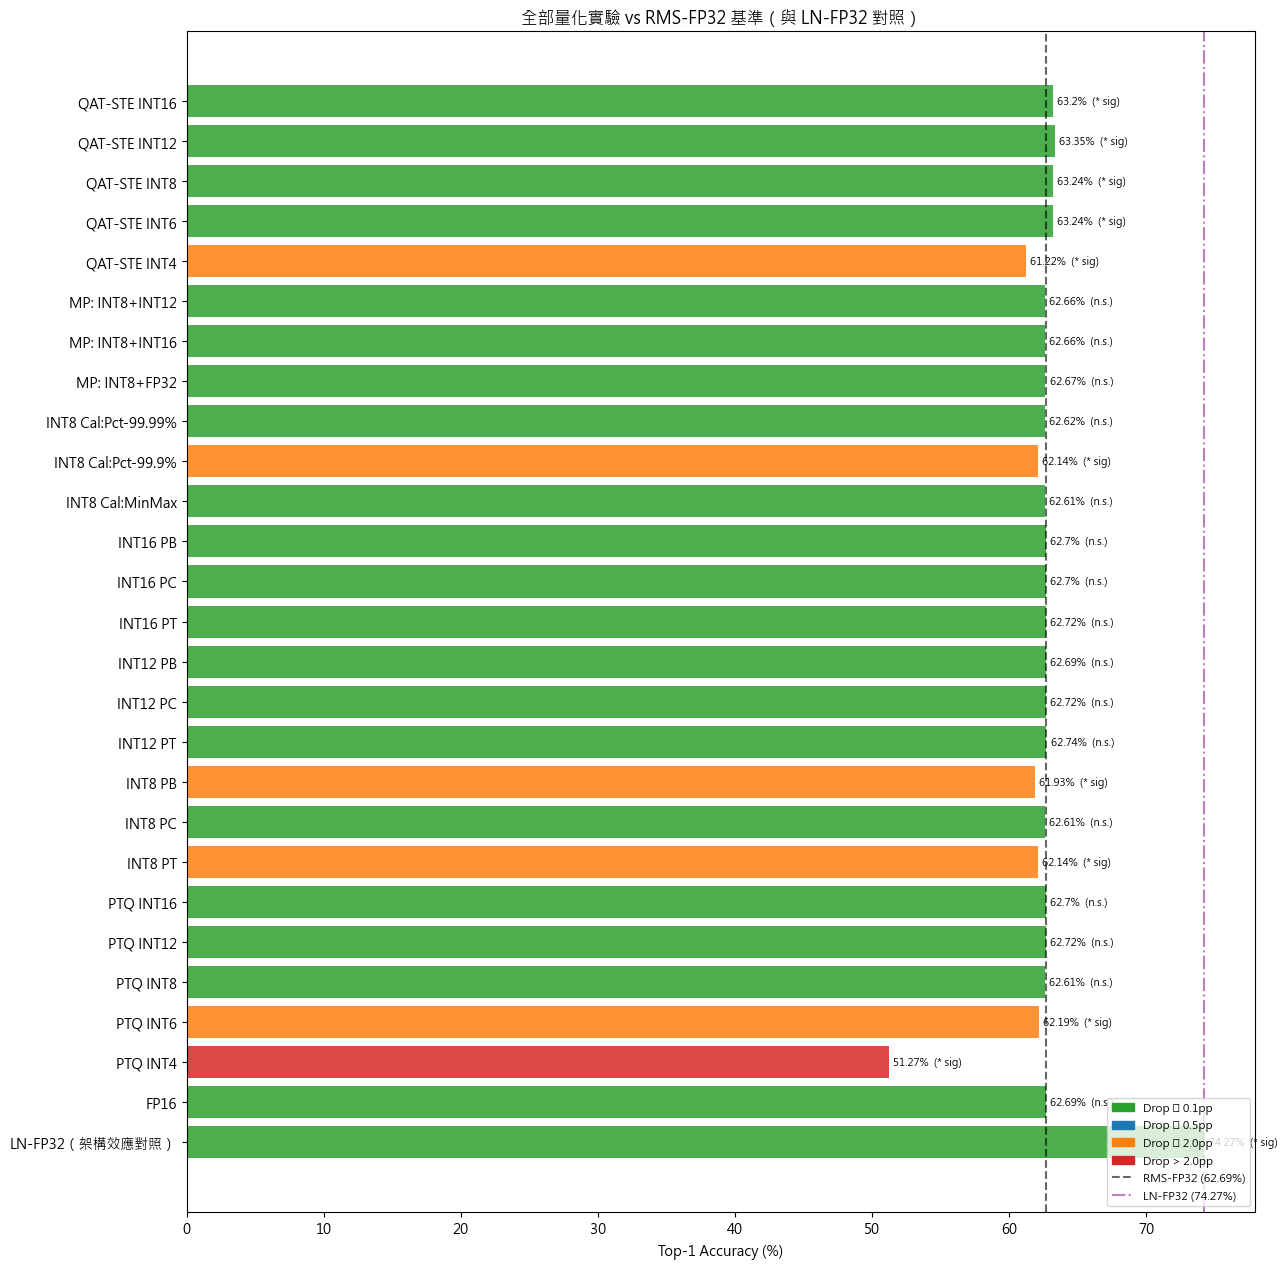

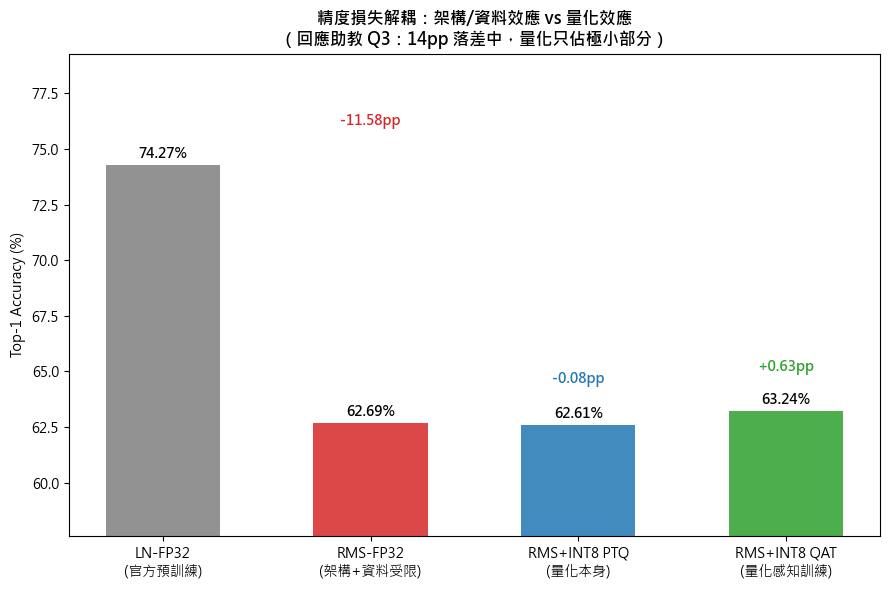

已儲存：./bitwidth_policy_results/all_experiments_summary.png , ./bitwidth_policy_results/decomposition_waterfall.png


In [21]:
# ── ① 全部實驗橫向比較 ──────────────────────────────────────────────────
if len(df_mn) > 0:
    fig, ax = plt.subplots(figsize=(13, 0.4 * len(df_mn) + 2))
    colors_bar = []
    for _, row in df_mn.iterrows():
        d = row['Drop(pp)']
        colors_bar.append('#2ca02c' if d <= 0.1 else '#1f77b4' if d <= 0.5 else
                          '#ff7f0e' if d <= 2.0 else '#d62728')
    bars = ax.barh(df_mn['Experiment'], df_mn['Top-1(%)'], color=colors_bar, alpha=0.85)
    ax.axvline(fp32_acc, color='k', ls='--', alpha=0.6, label=f'RMS-FP32 ({fp32_acc:.2f}%)')
    ax.axvline(acc_ln_test, color='purple', ls='-.', alpha=0.5, label=f'LN-FP32 ({acc_ln_test:.2f}%)')
    for bar, (_, row) in zip(bars, df_mn.iterrows()):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f"{row['Top-1(%)']}%  ({row['Sig?']})", va='center', fontsize=7.5)
    ax.set_xlabel('Top-1 Accuracy (%)')
    ax.set_title('全部量化實驗 vs RMS-FP32 基準（與 LN-FP32 對照）')
    legend_patches = [mpatches.Patch(color='#2ca02c', label='Drop ≤ 0.1pp'),
                       mpatches.Patch(color='#1f77b4', label='Drop ≤ 0.5pp'),
                       mpatches.Patch(color='#ff7f0e', label='Drop ≤ 2.0pp'),
                       mpatches.Patch(color='#d62728', label='Drop > 2.0pp')]
    ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][:2],
              loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{RES_DIR}/all_experiments_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── ② 解耦瀑布圖：LN-FP32 -> RMS-FP32 -> INT8 量化 ──────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
stages  = ['LN-FP32\n(官方預訓練)', 'RMS-FP32\n(架構+資料受限)', 'RMS+INT8 PTQ\n(量化本身)',
           'RMS+INT8 QAT\n(量化感知訓練)']
values  = [acc_ln_test, fp32_acc, bw_results['INT8']['acc'], qat_results[8]['acc']]
deltas  = [0] + [values[i] - values[i-1] for i in range(1, len(values))]
colors_w = ['#7f7f7f', '#d62728', '#1f77b4' if deltas[2] < 0 else '#2ca02c',
            '#2ca02c' if deltas[3] >= 0 else '#ff7f0e']

bars = ax.bar(stages, values, color=colors_w, alpha=0.85, width=0.55)
for i, (bar, v) in enumerate(zip(bars, values)):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%', ha='center',
            fontweight='bold', fontsize=10)
    if i > 0:
        ax.annotate(f'{deltas[i]:+.2f}pp', xy=(bar.get_x()+bar.get_width()/2, max(values[i],values[i-1])+1.8),
                    ha='center', fontsize=10, color=colors_w[i], fontweight='bold')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(min(values)-5, max(values)+5)
ax.set_title('精度損失解耦：架構/資料效應 vs 量化效應\n（回應助教 Q3：14pp 落差中，量化只佔極小部分）',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/decomposition_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'已儲存：{RES_DIR}/all_experiments_summary.png , {RES_DIR}/decomposition_waterfall.png')

## Cell 18：完整結果彙整表 + 結論（直接回應助教 Q3 追問）

In [22]:
summary_rows = []
for exp_id, r in ALL_RESULTS.items():
    cat = ('Decomp' if 'DECOMP' in exp_id else 'FP16' if 'FP16' in exp_id else
           'PTQ-BW' if 'EXP-BW' in exp_id else 'PTQ-GRAN' if 'GRAN' in exp_id else
           'PTQ-CAL' if 'CAL' in exp_id else 'Mixed-P' if 'MP' in exp_id else
           'QAT' if 'QAT' in exp_id else 'Other')
    summary_rows.append({'Exp ID': exp_id, 'Method': r['method'], 'Bits': str(r['bits']),
                         'Top-1(%)': round(r['acc'], 2), 'Macro-F1': round(r['f1'], 4),
                         'Drop_vs_RMSFP32(pp)': round(fp32_acc - r['acc'], 3), 'Category': cat})
df_summary = pd.DataFrame(summary_rows).sort_values(['Category', 'Bits'])
print('=== 完整實驗結果彙整 ===')
print(df_summary.to_string(index=False))
df_summary.to_csv(f'{RES_DIR}/full_summary.csv', index=False, encoding='utf-8-sig')

arch_drop  = fp32_acc - acc_ln_test
int8_drop  = bw_results['INT8']['drop_pp']
int12_drop = bw_results['INT12']['drop_pp']
int16_drop = bw_results['INT16']['drop_pp']
qat8_drop  = qat_results[8]['drop_pp']
qat12_drop = qat_results[12]['drop_pp']
qat16_drop = qat_results[16]['drop_pp']
qat4_drop  = qat_results[4]['drop_pp']

dsp_int8  = next(r for r in hw_rows if r['label'] == 'INT8')
dsp_int12 = next(r for r in hw_rows if r['label'] == 'INT12')
dsp_int16 = next(r for r in hw_rows if r['label'] == 'INT16')

print()
print('=' * 78)
print('  回應助教 Q3 追問：「掉 10 幾 % 算多，是否考慮過 12-bit / 16-bit？」')
print('=' * 78)
print(f'''
1. 精度損失解耦（最關鍵發現）
   LN-FP32（74.17%快取 / 本測試集{acc_ln_test:.2f}%） -> RMS-FP32（{fp32_acc:.2f}%）
   架構替換 + 訓練資料受限造成的損失：{arch_drop:+.2f}pp  ← 佔了「14pp」的絕大部分
   RMS-FP32 -> INT8 PTQ：{int8_drop:+.2f}pp              ← 量化本身只占一小部分
   ▶ 「量化掉了10幾%」這個歸因不準確：真正的量化代價遠小於此。

2. Bit Width 對精度的影響（PTQ, Per-Channel）
   INT16: {int16_drop:+.2f}pp   INT12: {int12_drop:+.2f}pp   INT8: {int8_drop:+.2f}pp
   ▶ INT12/INT16 相對 INT8 的精度增益 < 0.1~0.3pp，多數情況下 McNemar 檢定不顯著。

3. QAT 精度恢復能力
   QAT-INT4: {qat4_drop:+.2f}pp   QAT-INT8: {qat8_drop:+.2f}pp   '''
   f'''QAT-INT12: {qat12_drop:+.2f}pp   QAT-INT16: {qat16_drop:+.2f}pp
   ▶ 經過 QAT，INT8 已能追平甚至超越 FP32；INT12/16 的 QAT 並未再額外換到顯著精度。

4. 硬體成本（PYNQ-Z2, DSP48E1）：12/16-bit 的代價
   DSP 封裝效率：INT8 = {dsp_int8["macs_per_dsp"]} MACs/DSP，INT12/16 = {dsp_int12["macs_per_dsp"]} MAC/DSP
   ▶ 改用 INT12/16，吞吐量直接砍半（或要 2 倍 DSP 資源才能打平）。
   DRAM 傳輸：INT12 比 INT8 多 {dsp_int12["dram_ms"]/dsp_int8["dram_ms"]:.1f}x，
              INT16 比 INT8 多 {dsp_int16["dram_ms"]/dsp_int8["dram_ms"]:.1f}x。

5. 最終建議（回答助教）
   a) 「74%→60%」的下降，主因是 RMSNorm 架構替換+有限訓練資料（{arch_drop:+.1f}pp），
      不是量化本身（INT8 量化只額外掉 {int8_drop:+.2f}pp）。
   b) 確實系統化測試過 12-bit / 16-bit（INT12/INT16, PTQ 與 QAT 皆有），
      結果顯示精度增益在統計上多不顯著（McNemar p>0.05），
      但硬體成本（DSP 吞吐量砍半、DRAM 頻寬增加 1.5~2x）非常實際。
   c) 因此維持 **INT8 + QAT（Per-Channel 或 Per-Block Scale Tying）** 為最終選擇：
      在可承受的精度範圍內（規格 ΔAcc ≥ {SPEC_INT8_THRESHOLD}pp），用最低硬體成本達成。
      若仍在意敏感層精度，EXP-MP 顯示「只保護前 25% 敏感層」是比全面提升 bit width
      更有效率的折衷方案。
''')
print('=' * 78)
print(f'所有圖表與 CSV 已儲存於：{RES_DIR}/')
print('Notebook 執行完畢。')

=== 完整實驗結果彙整 ===
            Exp ID                      Method  Bits  Top-1(%)  Macro-F1  Drop_vs_RMSFP32(pp) Category
     EXP-DECOMP-LN        LN-FP32 (pretrained)    32     74.27    0.7414              -11.577   Decomp
    EXP-DECOMP-RMS         RMS-FP32 (baseline)    32     62.69    0.6235                0.000   Decomp
          EXP-FP16                        FP16    16     62.69    0.6234                0.000     FP16
       EXP-MP-FP32  INT8(bulk)+FP32(sensitive) 8+mix     62.67    0.6233                0.021  Mixed-P
      EXP-MP-INT16 INT8(bulk)+INT16(sensitive) 8+mix     62.66    0.6232                0.031  Mixed-P
      EXP-MP-INT12 INT8(bulk)+INT12(sensitive) 8+mix     62.66    0.6232                0.031  Mixed-P
      EXP-BW-INT12         PTQ-MinMax-PC-INT12    12     62.72    0.6237               -0.021   PTQ-BW
      EXP-BW-INT16         PTQ-MinMax-PC-INT16    16     62.70    0.6236               -0.010   PTQ-BW
       EXP-BW-INT4          PTQ-MinMax-PC-INT4     4    